In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [2]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

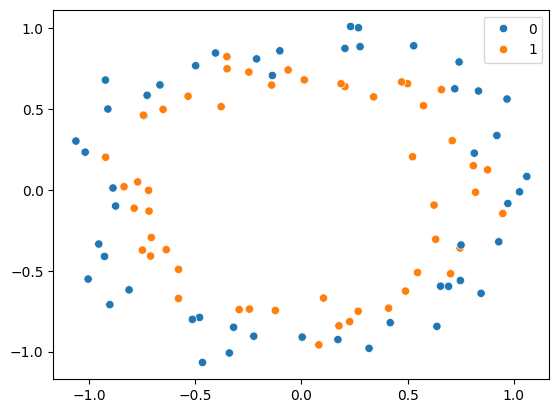

In [3]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [5]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

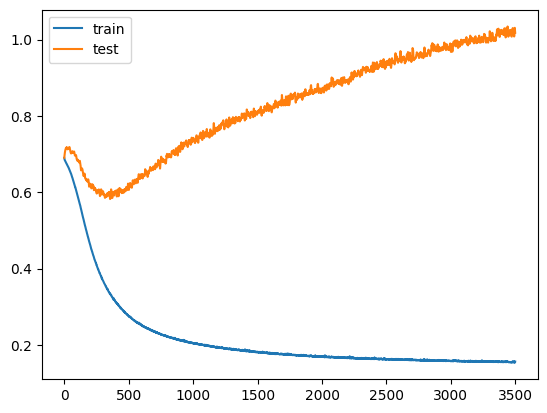

In [8]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [12]:
print("y_test:", np.unique(y_test.ravel()))

pred = model.predict(X_test)

print("Prediction shape:", pred.shape)
print("First 10 predictions:", pred[:10])

y_test: [0 1]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Prediction shape: (20, 1)
First 10 predictions: [[5.0427127e-01]
 [8.1146779e-03]
 [9.9017578e-01]
 [8.9883268e-01]
 [1.8295219e-05]
 [9.7507459e-01]
 [6.4523937e-07]
 [2.1018502e-03]
 [9.1332935e-02]
 [2.8471959e-01]]


In [13]:
print(X_test.shape)
print(y_test.shape)
print(model.summary())

(20, 2)
(20,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,077 (12.02 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,052 (8.02 KB)

None


In [14]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nMODEL SUMMARY:")
model.summary()

X_test shape: (20, 2)
y_test shape: (20,)

MODEL SUMMARY:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,077 (12.02 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,052 (8.02 KB)

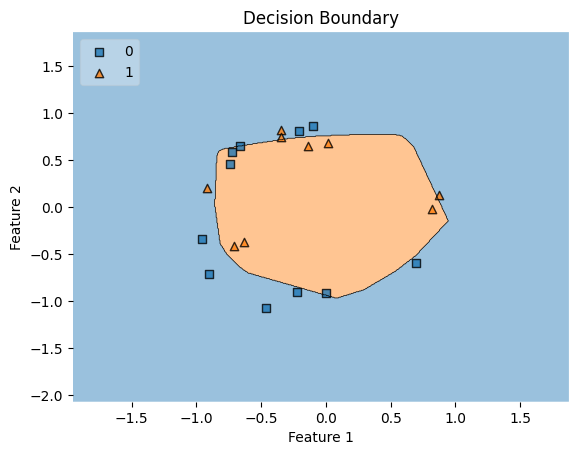

In [15]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import numpy as np

# Wrapper for the Keras model
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        predictions = self.model.predict(X, verbose=0)
        return (predictions.ravel() >= 0.5).astype(int)

# Create wrapper
wrapper = KerasClassifierWrapper(model)

# Plot decision regions
plot_decision_regions(
    X_test,
    y_test.ravel(),
    clf=wrapper,
    legend=2
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.show()

Early Stopping

In [16]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [17]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [18]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [23]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6250 - loss: 0.6618 - val_accuracy: 0.3500 - val_loss: 0.7130
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6375 - loss: 0.6609 - val_accuracy: 0.4500 - val_loss: 0.7115
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6500 - loss: 0.6601 - val_accuracy: 0.4500 - val_loss: 0.7108
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6625 - loss: 0.6594 - val_accuracy: 0.4500 - val_loss: 0.7097
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6375 - loss: 0.6584 - val_accuracy: 0.4500 - val_loss: 0.7089
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6250 - loss: 0.6579 - val_accuracy: 0.4500 - val_loss: 0.7080
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6375 - loss: 0.6568 - val_accuracy: 0.4500 - val_loss: 0.7083
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6500 - loss: 0.6563 - val_accuracy: 0.4500 - v

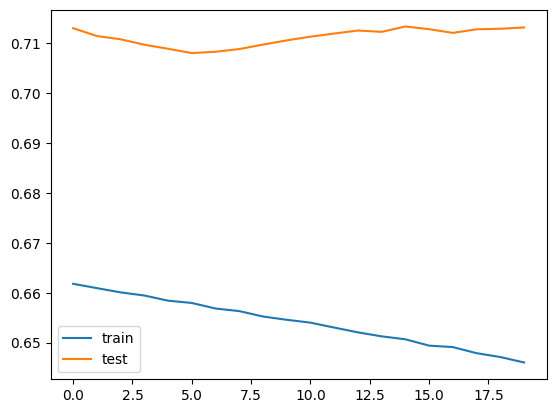

In [24]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

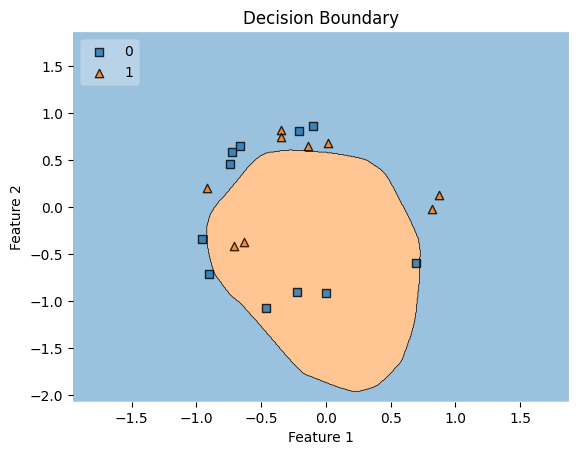

In [26]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import numpy as np

# Wrapper for the Keras model
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        predictions = self.model.predict(X, verbose=0)
        return (predictions.ravel() >= 0.5).astype(int)

# Create wrapper
wrapper = KerasClassifierWrapper(model)

# Plot decision regions
plot_decision_regions(
    X_test,
    y_test.ravel(),
    clf=wrapper,
    legend=2
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")
plt.show()